In [1]:
import os
import mne
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from collections import Counter

import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, KFold

from scipy import stats
from scipy.stats import ttest_rel
# from scipy.stats import false_discovery_control

Matplotlib is building the font cache; this may take a moment.


# Read data

In [2]:
data_folder = '/mnt/s3-data2/amiftakhova/OCD/OCD/'
folders = [x for x in os.listdir(data_folder) if os.path.isdir(data_folder + x)]
inside_folders = []
for fldr in folders:
    ins = [fldr + '/' + x for x in os.listdir(data_folder + fldr) if os.path.isdir(data_folder + fldr + '/' + x)]
    if len(ins) > 0:
        inside_folders.extend(ins)
    else:
        inside_folders.append(fldr)
fldr2label = {inside_folders[i]: i for i in range(len(inside_folders))}
fldr2label

{'Response to stress (57)/Somatoform_disorder (12)': 0,
 'Response to stress (57)/Stress_disorder (24)': 1,
 'Response to stress (57)/eating_disorder (14)': 2,
 'Response to stress (57)/neurasthenia (7)': 3,
 'anxiety_disorder (81)/ADD (47)': 4,
 'anxiety_disorder (81)/AFD (18)': 5,
 'anxiety_disorder (81)/general_AD (16)': 6,
 'bipolar_disorder (61)/BPD_1(26)': 7,
 'bipolar_disorder (61)/BPD_2(25)': 8,
 'bipolar_disorder (61)/Cyclothymia(10)': 9,
 'controls (157)': 10,
 'depression (109)/mild (29)': 11,
 'depression (109)/moderade (47)': 12,
 'depression (109)/severe (32)': 13,
 'personality_disorder (56)': 14}

In [3]:
label2class = {
    4: 0, 5: 0, 6: 0, # anxiety
    7: 1, 8: 1, 9: 1, # bipolar
    10: 2, # control
    11: 3, 12: 3, 13: 3, # depression
    14: 4, # personality disorder,
    0: 5, 1: 5, 2: 5, 3: 5# stress
}

class2name = {0: 'anxiety', 1: 'bipolar', 2: 'control', 3: 'depression', 4: 'personality disorder', 5: 'stress'}
name2class = {v: k for k, v in class2name.items()}

In [4]:
og_files = []
zg_files = []
og_labels = []
zg_labels = []
for fldr in inside_folders:
    pth =  data_folder + fldr
    og_pths = [x for x in os.listdir(pth) if x.lower().endswith('.edf') and ('og.' in x.lower() or '_ог.' in x.lower() or ' ог.' in x.lower() or 'eo.' in x.lower() or '_eo' in x.lower() or '_of' in x.lower())]
    zg_pths = [x for x in os.listdir(pth) if x.lower().endswith('.edf') and ('zg.' in x.lower() or 'зог.' in x.lower() or 'зг.' in x.lower() or 'ec.' in x.lower() or 'fon.' in x.lower() or '_ec' in x.lower() or 'eс.' in x.lower())]
    left = [x for x in os.listdir(pth) if x not in og_pths and x not in zg_pths]
    if len(left) > 0:
        print(pth, left)
    for f in og_pths:
        og_files.append(pth + '/' + f)
        og_labels.append(fldr2label[fldr])
    for f in zg_pths:
        zg_files.append(pth + '/' + f)
        zg_labels.append(fldr2label[fldr])

print(f'Number of files for open eyes: {len(og_files)}')
print(f'Number of files for closed eyes: {len(zg_files)}')

# ensured that og_files[i] is the pair for zg_files[i]

Number of files for open eyes: 518
Number of files for closed eyes: 518


In [5]:
lengths_og = []
lengths_zg = []
for i in tqdm(range(len(og_files))):
    og_file = og_files[i]
    zg_file = zg_files[i]
    try:
        og_sample = mne.io.read_raw_edf(og_file, verbose=False)
        og_len = 1.0 * len(og_sample) / og_sample.info['sfreq']
        zg_sample = mne.io.read_raw_edf(zg_file, verbose=False)
        zg_len = 1.0 * len(zg_sample) / zg_sample.info['sfreq']
        lengths_og.append(og_len)
        lengths_zg.append(zg_len)
    except Exception as e:
        print(f, e)
        lengths_og.append(0)
        lengths_zg.append(0)

  0%|          | 0/518 [00:00<?, ?it/s]

ИОДКОВСКАЯ ОЛЬГА 14 Ф60-3_zg.EDF could not convert string to float: ''
ИОДКОВСКАЯ ОЛЬГА 14 Ф60-3_zg.EDF could not convert string to float: ''


In [6]:
ids = np.argwhere(np.array(lengths_zg) >= 20.0).flatten()
ids2 = np.argwhere(np.array(lengths_og) >= 20.0).flatten()

# Baseline, from 20 to 60

In [8]:
ids = np.argwhere(np.array(lengths_zg) >= 60.0).flatten()
tmp_labels = np.array(zg_labels)[ids]
classes = [label2class[x] for x in tmp_labels]
cnt = Counter(classes)
for k, v in cnt.items():
    print(class2name[k], v)

stress 18
anxiety 18
bipolar 27
control 122
depression 22
personality disorder 5


In [10]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

labels = classes
f1_scores_macro = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    preds = [2] * len(test)
    y_test = np.array(labels)[test]
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))

print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')

avg macro-f1: 0.12175486205336952, std: 0.0022414313330373302


# DE features, from 20 to 50

In [50]:
ids = np.argwhere(np.array(lengths_zg) >= 50.0).flatten()

In [51]:
tmp_labels = np.array(zg_labels)[ids]
classes = [label2class[x] for x in tmp_labels]
cnt = Counter(classes)
for k, v in cnt.items():
    print(class2name[k], v)

stress 24
anxiety 27
bipolar 30
control 130
depression 34
personality disorder 12


In [32]:
def compute_features(data, s_freq=250, pairs=[], n_channels=19):
    freq_bands = np.array([1, 4, 8, 13, 30])

    psd, freqs = mne.time_frequency.psd_array_welch(data, sfreq=s_freq, fmin=1, fmax=30, n_fft=512, n_per_seg=s_freq, window='hann', average=None, verbose=False)

    # compute ES and DE
    differential_entropy = np.zeros((psd.shape[0], len(freq_bands) - 1, psd.shape[2]))
    energy_spectrum = np.zeros((psd.shape[0], len(freq_bands) - 1, psd.shape[2]))

    for i in range(n_channels):
        for j in range(len(freq_bands) - 1):
            band_indices = np.where((freqs >= freq_bands[j]) & (freqs < freq_bands[j+1]))[0]
            if len(band_indices) > 0:
                band_psd = psd[i, band_indices]
                band_variance = np.mean(band_psd, axis=0)
                differential_entropy[i, j] = 0.5 * np.log(2 * np.pi * np.e * band_variance)
                energy_spectrum[i, j] = band_variance
    # compute asymmetry features
    left = differential_entropy[[x[0] for x in pairs]]
    right = differential_entropy[[x[1] for x in pairs]]
    dasm = left - right
    rasm = left / right
    return energy_spectrum, differential_entropy, dasm, rasm

In [53]:
# calculate features for the first 20s of each recording
n_channels = 19
s_freq = 250

seconds = [5, 10, 15, 20, 30, 40, 50]

name_pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('F7', 'F8'), ('C3', 'C4'), ('T3', 'T4'), ('P3', 'P4'), ('T5', 'T6'), ('O1', 'O2')]
idx_pairs = [(0, 1), (2, 4), (5, 6), (9, 11), (7, 8), (14, 16), (12, 13), (17, 18)]
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

results = {}

for sec in tqdm(seconds):
    cleaned_labels_zg = []
    es_features_zg = []
    de_features_zg = []
    dasm_features_zg = []
    rasm_features_zg = []

    for i in tqdm(ids):
        try:
            path = zg_files[i]
            sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
            sample = sample.resample(s_freq, verbose=False)
            # skip faulty data for now
            if 'chan' in sample.ch_names[0].lower():
                continue

            sample = sample.filter(l_freq=6, h_freq=26, method='iir', verbose=False)
            channels = sample.ch_names
            to_drop = channels[19:]

            new_idx = []
            skip = False
            for ch in channels2use:
                found = False
                for k in range(19):
                    if ch in channels[k]:
                        new_idx.append(k)
                        found = True
                        break
                if not found:
                    skip = True
                    break
            if skip:
                continue

            data = sample.get_data()[new_idx, :int(sec * s_freq)]

            es, de, dasm, rasm = compute_features(data, s_freq, idx_pairs)
            es_features_zg.append(es)
            de_features_zg.append(de)
            dasm_features_zg.append(dasm)
            rasm_features_zg.append(rasm)
            cleaned_labels_zg.append(label2class[zg_labels[i]])
        except Exception as e:
            print(e)
            print(path)
    es_features_zg = np.array(es_features_zg)
    de_features_zg = np.array(de_features_zg)
    dasm_features_zg = np.array(dasm_features_zg)
    rasm_features_zg = np.array(rasm_features_zg)
    cleaned_labels_zg = np.array(cleaned_labels_zg)

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    f1_scores_macro = []
    f1_scores_micro = []
    accuracies = []

    labels = cleaned_labels_zg

    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        X_train = np.concatenate((de_features_zg[train].reshape(-1, 19 * 4 * sec), dasm_features_zg[train].reshape(-1, 8 * 4 * sec), rasm_features_zg[train].reshape(-1, 8 * 4 * sec)), axis=1)
        X_test = np.concatenate((de_features_zg[test].reshape(-1, 19 * 4 * sec), dasm_features_zg[test].reshape(-1, 8 * 4 * sec), rasm_features_zg[test].reshape(-1, 8 * 4 * sec)), axis=1)
        y_train = labels[train]
        y_test = labels[test]
        clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        f1_scores_macro.append(f1_score(y_test, preds, average='macro'))

    # print(f1_scores_macro)
    print(f'SECONDS: {sec}')
    print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')
    results[sec] = f1_scores_macro

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/257 [00:00<?, ?it/s]

SECONDS: 5
avg macro-f1: 0.41389731759059495, std: 0.08289293683451658


  0%|          | 0/257 [00:00<?, ?it/s]

SECONDS: 10
avg macro-f1: 0.4122774272219333, std: 0.08006284235889498


...

SECONDS: 30
avg macro-f1: 0.4479552244761879, std: 0.07017804322681508


  0%|          | 0/257 [00:00<?, ?it/s]

SECONDS: 40
avg macro-f1: 0.4387195885461056, std: 0.07296469201204443


  0%|          | 0/257 [00:00<?, ?it/s]

SECONDS: 50
avg macro-f1: 0.46110134089877286, std: 0.05182884482099358


# DE features, 20 to 60

In [54]:
ids = np.argwhere(np.array(lengths_zg) >= 60.0).flatten()
tmp_labels = np.array(zg_labels)[ids]
classes = [label2class[x] for x in tmp_labels]
cnt = Counter(classes)
for k, v in cnt.items():
    print(class2name[k], v)

stress 18
anxiety 18
bipolar 27
control 122
depression 22
personality disorder 5


In [55]:
# calculate features for the first 20s of each recording
n_channels = 19
s_freq = 250

seconds = [5, 10, 15, 20, 30, 40, 50, 60]

name_pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('F7', 'F8'), ('C3', 'C4'), ('T3', 'T4'), ('P3', 'P4'), ('T5', 'T6'), ('O1', 'O2')]
idx_pairs = [(0, 1), (2, 4), (5, 6), (9, 11), (7, 8), (14, 16), (12, 13), (17, 18)]
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

results_2 = {}

for sec in tqdm(seconds):
    cleaned_labels_zg = []
    es_features_zg = []
    de_features_zg = []
    dasm_features_zg = []
    rasm_features_zg = []

    for i in tqdm(ids):
        try:
            path = zg_files[i]
            sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
            sample = sample.resample(s_freq, verbose=False)
            # skip faulty data for now
            if 'chan' in sample.ch_names[0].lower():
                continue

            sample = sample.filter(l_freq=6, h_freq=26, method='iir', verbose=False)
            channels = sample.ch_names
            to_drop = channels[19:]

            new_idx = []
            skip = False
            for ch in channels2use:
                found = False
                for k in range(19):
                    if ch in channels[k]:
                        new_idx.append(k)
                        found = True
                        break
                if not found:
                    skip = True
                    break
            if skip:
                continue

            data = sample.get_data()[new_idx, :int(sec * s_freq)]

            es, de, dasm, rasm = compute_features(data, s_freq, idx_pairs)
            es_features_zg.append(es)
            de_features_zg.append(de)
            dasm_features_zg.append(dasm)
            rasm_features_zg.append(rasm)
            cleaned_labels_zg.append(label2class[zg_labels[i]])
        except Exception as e:
            print(e)
            print(path)
    es_features_zg = np.array(es_features_zg)
    de_features_zg = np.array(de_features_zg)
    dasm_features_zg = np.array(dasm_features_zg)
    rasm_features_zg = np.array(rasm_features_zg)
    cleaned_labels_zg = np.array(cleaned_labels_zg)

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    f1_scores_macro = []
    f1_scores_micro = []
    accuracies = []

    labels = cleaned_labels_zg

    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        X_train = np.concatenate((de_features_zg[train].reshape(-1, 19 * 4 * sec), dasm_features_zg[train].reshape(-1, 8 * 4 * sec), rasm_features_zg[train].reshape(-1, 8 * 4 * sec)), axis=1)
        X_test = np.concatenate((de_features_zg[test].reshape(-1, 19 * 4 * sec), dasm_features_zg[test].reshape(-1, 8 * 4 * sec), rasm_features_zg[test].reshape(-1, 8 * 4 * sec)), axis=1)
        y_train = labels[train]
        y_test = labels[test]
        clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        f1_scores_macro.append(f1_score(y_test, preds, average='macro'))

    # print(f1_scores_macro)
    print(f'SECONDS: {sec}')
    print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')
    results_2[sec] = f1_scores_macro

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/212 [00:00<?, ?it/s]

SECONDS: 5
avg macro-f1: 0.4880780142005043, std: 0.056308001252868535


  0%|          | 0/212 [00:00<?, ?it/s]

SECONDS: 10
avg macro-f1: 0.5108851965644419, std: 0.06507999886618863


...

SECONDS: 40
avg macro-f1: 0.5399130115167851, std: 0.055781656181564145


  0%|          | 0/212 [00:00<?, ?it/s]

SECONDS: 50
avg macro-f1: 0.535391955684905, std: 0.07022060058618151


  0%|          | 0/212 [00:00<?, ?it/s]

SECONDS: 60
avg macro-f1: 0.536257756550706, std: 0.06960679895357091


In [57]:
with open('results/de_5_50.json', 'w') as f:
    json.dump(results, f)

with open('results/de_5_60.json', 'w') as f:
    json.dump(results_2, f)

# Gradient features, 20 to 50

In [58]:
ids = np.argwhere(np.array(lengths_zg) >= 50.0).flatten()
tmp_labels = np.array(zg_labels)[ids]
classes = [label2class[x] for x in tmp_labels]
cnt = Counter(classes)
for k, v in cnt.items():
    print(class2name[k], v)

stress 24
anxiety 27
bipolar 30
control 130
depression 34
personality disorder 12


In [42]:
def get_frontal_features(ch_names, psd):
    indices = [i for i in range(len(ch_names)) if 'F3' in ch_names[i] or 'Fz' in ch_names[i] or 'F4' in ch_names[i]]
    return psd[indices]

def get_central_features(ch_names, psd):
    indices = [i for i in range(len(ch_names)) if 'C3' in ch_names[i] or 'Cz' in ch_names[i] or 'C4' in ch_names[i]]
    return psd[indices]

def get_parietal_features(ch_names, psd):
    indices = [i for i in range(len(ch_names)) if 'P3' in ch_names[i] or 'Pz' in ch_names[i] or 'P4' in ch_names[i]]
    return psd[indices]

def get_frontal2central_gradient(ch_names, psd):
    frontal_indices = [i for i in range(len(ch_names)) if 'F3' in ch_names[i] or 'Fz' in ch_names[i] or 'F4' in ch_names[i]]
    central_indices = [i for i in range(len(ch_names)) if 'C3' in ch_names[i] or 'Cz' in ch_names[i] or 'C4' in ch_names[i]]
    return np.sum(psd[frontal_indices], axis=0) / np.sum(psd[central_indices], axis=0)

def get_frontal2parietal_gradient(ch_names, psd):
    frontal_indices = [i for i in range(len(ch_names)) if 'F3' in ch_names[i] or 'Fz' in ch_names[i] or 'F4' in ch_names[i]]
    parietal_indices = [i for i in range(len(ch_names)) if 'P3' in ch_names[i] or 'Pz' in ch_names[i] or 'P4' in ch_names[i]]
    return np.sum(psd[frontal_indices], axis=0) / np.sum(psd[parietal_indices], axis=0)

def get_central2parietal_gradient(ch_names, psd):
    central_indices = [i for i in range(len(ch_names)) if 'C3' in ch_names[i] or 'Cz' in ch_names[i] or 'C4' in ch_names[i]]
    parietal_indices = [i for i in range(len(ch_names)) if 'P3' in ch_names[i] or 'Pz' in ch_names[i] or 'P4' in ch_names[i]]
    return np.sum(psd[central_indices], axis=0) / np.sum(psd[parietal_indices], axis=0)

def get_front2back_gradient(ch_names, psd):
    front_indices = [i for i in range(len(ch_names)) if any([x in ch_names[i] for x in ['Fp1', 'Fp2', 'F3', 'Fz', 'F4']])]  
    back_indices = [i for i in range(len(ch_names)) if any([x in ch_names[i] for x in ['O1', 'O2', 'P3', 'Pz', 'P4']])]
    return np.sum(psd[front_indices], axis=0) / np.sum(psd[back_indices], axis=0)

def get_left2right_gradient(ch_names, psd):
    left_indices = [i for i in range(len(ch_names)) if any([x in ch_names[i] for x in ['F3', 'C3', 'P3', 'O1']])]
    right_indices = [i for i in range(len(ch_names)) if any([x in ch_names[i] for x in ['F4', 'C4', 'P4', 'O2']])]
    return np.sum(psd[left_indices], axis=0) / np.sum(psd[right_indices], axis=0)

In [60]:
s_freq = 250
seconds = [5, 10, 15, 20, 30, 40, 50]

channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(8, 13), (13, 26)]

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}

results = {}

for sec in seconds:
    band2features = {fb: [] for fb in freq_bands}

    for i in tqdm(ids):
        path = zg_files[i]
        try:
            sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
            sample = sample.resample(s_freq, verbose=False)
        except Exception as e:
            print(f'skipped {path}')
            continue
        # skip faulty data for now
        if 'chan' in sample.ch_names[0].lower():
            print(f'skipped {path}')
            continue
        sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
        # get only necessary channels, reorder them
        channels = sample.ch_names
        to_drop = channels[19:]
        sample.drop_channels(to_drop)
        new_idx = []
        skip = False
        for ch in channels2use:
            found = False
            for k in range(19):
                if ch in channels[k]:
                    new_idx.append(k)
                    found = True
                    break
            if not found:
                skip = True
                break
        if skip:
            print(f'skipped {path}')
            continue
        
        data = sample.get_data()[new_idx, :int(sec * s_freq)]

        for freq_band in freq_bands:
            psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
            band2features[freq_band].append({
                'frontal2parietal': get_frontal2parietal_gradient(channels, psd),
                'front2back': get_front2back_gradient(channels, psd),
                'left2right': get_left2right_gradient(channels, psd),
                'label': zg_labels[i]
            })

    freq_bands = [(8, 13), (13, 26)]
    num_samples = len(band2features[freq_bands[0]])
    frontal2parietal_features = [np.concatenate([band2features[freq_bands[0]][i]['frontal2parietal'], band2features[freq_bands[1]][i]['frontal2parietal']]) for i in range(num_samples)]
    front2back_features = [np.concatenate([band2features[freq_bands[0]][i]['front2back'], band2features[freq_bands[1]][i]['front2back']]) for i in range(num_samples)]
    left2right_features = [np.concatenate([band2features[freq_bands[0]][i]['left2right'], band2features[freq_bands[1]][i]['left2right']]) for i in range(num_samples)]
    labels = [label2class[x['label']] for x in band2features[freq_bands[0]]]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    features = []
    for i in range(len(labels)):
        features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i]]))
    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = SVC(kernel='linear', random_state=92)
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))
    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')
    results[sec] = f1_scores

  0%|          | 0/257 [00:00<?, ?it/s]

skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EC_free.edf
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/MANUILOVA_ELENA_55_zg.edf
	F1 score: 0.43010039255633814, std: 0.04819099528986388


  0%|          | 0/257 [00:00<?, ?it/s]

skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EC_free.edf
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/MANUILOVA_ELENA_55_zg.edf
	F1 score: 0.41627507640612443, std: 0.04357095787431656


  0%|          | 0/257 [00:00<?, ?it/s]

...

skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EC_free.edf
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/MANUILOVA_ELENA_55_zg.edf
	F1 score: 0.425001036882067, std: 0.0668428013792398


  0%|          | 0/257 [00:00<?, ?it/s]

skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EC_free.edf
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/MANUILOVA_ELENA_55_zg.edf
	F1 score: 0.4406275753954252, std: 0.05379091274675176


  0%|          | 0/257 [00:00<?, ?it/s]

skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EC_free.edf
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/MANUILOVA_ELENA_55_zg.edf
	F1 score: 0.4406580612042797, std: 0.07284642032480484


# Gradient features, 20 to 60

In [64]:
ids = np.argwhere(np.array(lengths_zg) >= 60.0).flatten()
tmp_labels = np.array(zg_labels)[ids]
classes = [label2class[x] for x in tmp_labels]
cnt = Counter(classes)
for k, v in cnt.items():
    print(class2name[k], v)

stress 18
anxiety 18
bipolar 27
control 122
depression 22
personality disorder 5


In [65]:
s_freq = 250
seconds = [5, 10, 15, 20, 30, 40, 50, 60]

channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(8, 13), (13, 26)]

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}

results_2 = {}

for sec in seconds:
    band2features = {fb: [] for fb in freq_bands}

    for i in tqdm(ids):
        path = zg_files[i]
        try:
            sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
            sample = sample.resample(s_freq, verbose=False)
        except Exception as e:
            print(f'skipped {path}')
            continue
        # skip faulty data for now
        if 'chan' in sample.ch_names[0].lower():
            print(f'skipped {path}')
            continue
        sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
        # get only necessary channels, reorder them
        channels = sample.ch_names
        to_drop = channels[19:]
        sample.drop_channels(to_drop)
        new_idx = []
        skip = False
        for ch in channels2use:
            found = False
            for k in range(19):
                if ch in channels[k]:
                    new_idx.append(k)
                    found = True
                    break
            if not found:
                skip = True
                break
        if skip:
            print(f'skipped {path}')
            continue
        
        data = sample.get_data()[new_idx, :int(sec * s_freq)]

        for freq_band in freq_bands:
            psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
            band2features[freq_band].append({
                'frontal2parietal': get_frontal2parietal_gradient(channels, psd),
                'front2back': get_front2back_gradient(channels, psd),
                'left2right': get_left2right_gradient(channels, psd),
                'label': zg_labels[i]
            })

    freq_bands = [(8, 13), (13, 26)]
    num_samples = len(band2features[freq_bands[0]])
    frontal2parietal_features = [np.concatenate([band2features[freq_bands[0]][i]['frontal2parietal'], band2features[freq_bands[1]][i]['frontal2parietal']]) for i in range(num_samples)]
    front2back_features = [np.concatenate([band2features[freq_bands[0]][i]['front2back'], band2features[freq_bands[1]][i]['front2back']]) for i in range(num_samples)]
    left2right_features = [np.concatenate([band2features[freq_bands[0]][i]['left2right'], band2features[freq_bands[1]][i]['left2right']]) for i in range(num_samples)]
    labels = [label2class[x['label']] for x in band2features[freq_bands[0]]]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    features = []
    for i in range(len(labels)):
        features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i]]))
    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = SVC(kernel='linear', random_state=92)
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))
    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')
    results_2[sec] = f1_scores

  0%|          | 0/212 [00:00<?, ?it/s]

skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EC_free.edf
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/MANUILOVA_ELENA_55_zg.edf
	F1 score: 0.4688005869790798, std: 0.04324571006949949


  0%|          | 0/212 [00:00<?, ?it/s]

skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EC_free.edf
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/MANUILOVA_ELENA_55_zg.edf
	F1 score: 0.4684639538322912, std: 0.036735820783010575


  0%|          | 0/212 [00:00<?, ?it/s]

...

skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EC_free.edf
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/MANUILOVA_ELENA_55_zg.edf
	F1 score: 0.4993285004237385, std: 0.03427098398618089


  0%|          | 0/212 [00:00<?, ?it/s]

skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EC_free.edf
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/MANUILOVA_ELENA_55_zg.edf
	F1 score: 0.5137887462456865, std: 0.06817361339338417


  0%|          | 0/212 [00:00<?, ?it/s]

skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EC_free.edf
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/MANUILOVA_ELENA_55_zg.edf
	F1 score: 0.5385203509724954, std: 0.07198697755247649


In [66]:
with open('results/grad_5_60.json', 'w') as f:
    json.dump(results_2, f)

# Envelope correlations, 20 to 60

In [11]:
import numpy as np
import mne
from scipy.signal import hilbert
from mne_connectivity import envelope_correlation

In [12]:
freq_bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30)
}

def compute_envelope_features(epochs, freq_bands):
    envelope_features = []
    for band, (l_freq, h_freq) in freq_bands.items():
        # Band-pass filter
        epochs_band = epochs.copy().filter(l_freq=l_freq, h_freq=h_freq, verbose=False)
        data = epochs_band.get_data()  # Shape (n_epochs, n_channels, n_times)
        
        # Compute envelope using Hilbert transform
        analytic = hilbert(data)
        envelope = np.abs(analytic)
        
        # Compute statistics (mean and standard deviation)
        mean_env = np.mean(envelope, axis=-1)  # (n_epochs, n_channels)
        std_env = np.std(envelope, axis=-1)
        
        # Concatenate features for this band
        features = np.concatenate([mean_env, std_env], axis=0)
        envelope_features.append(features)
    
    return np.hstack(envelope_features)

def compute_correlation_features(epochs, freq_bands, low_pass=4, new_sfreq=8):
    corr_features = []
    sfreq = epochs.info['sfreq']
    
    for band, (l_freq, h_freq) in freq_bands.items():
        # Band-pass filter
        epochs_band = epochs.copy().filter(l_freq=l_freq, h_freq=h_freq, verbose=False)
        data = epochs_band.get_data()  # Shape (n_epochs, n_channels, n_times)
        
        # Compute envelope
        analytic = hilbert(data)
        envelope = np.abs(analytic)
        
        # Low-pass filter the envelope
        envelope_low = mne.filter.filter_data(
            envelope, sfreq=sfreq, l_freq=None, h_freq=low_pass, method='iir', verbose=False
        )
        
        # Downsample the envelope
        envelope_down = mne.filter.resample(
            envelope_low, down=sfreq / new_sfreq, axis=-1, verbose=False
        )
        
        # Compute envelope correlations
        n_channels, _ = envelope_down.shape
        corr = np.corrcoef(envelope_down)
        
        # Extract upper triangle indices
        triu_inds = np.triu_indices(n_channels, k=1)
        corr_flat = corr[triu_inds[0], triu_inds[1]]
        corr_features.append(corr_flat)
    
    return np.hstack(corr_features)

In [52]:
ids = np.argwhere(np.array(lengths_zg) >= 60.0).flatten()
tmp_labels = np.array(zg_labels)[ids]
classes = [label2class[x] for x in tmp_labels]
cnt = Counter(classes)
for k, v in cnt.items():
    print(class2name[k], v)

stress 18
anxiety 18
bipolar 27
control 122
depression 22
personality disorder 5


In [55]:
# calculate features for the first 20s of each recording
n_channels = 19
s_freq = 250

seconds = [5, 10, 15, 20, 30, 40, 50, 60]

name_pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('F7', 'F8'), ('C3', 'C4'), ('T3', 'T4'), ('P3', 'P4'), ('T5', 'T6'), ('O1', 'O2')]
idx_pairs = [(0, 1), (2, 4), (5, 6), (9, 11), (7, 8), (14, 16), (12, 13), (17, 18)]
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

results = {}

for sec in seconds:
    cleaned_labels_zg = []
    envelopes = []
    correlations = []

    for i in tqdm(ids):
        try:
            path = zg_files[i]
            sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
            sample = sample.resample(s_freq, verbose=False)
            # skip faulty data for now
            if 'chan' in sample.ch_names[0].lower():
                continue

            sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
            channels = sample.ch_names
            to_drop = channels[19:]

            new_idx = []
            skip = False
            for ch in channels2use:
                found = False
                for k in range(19):
                    if ch in channels[k]:
                        new_idx.append(k)
                        found = True
                        break
                if not found:
                    skip = True
                    break
            if skip:
                continue

            # data = sample.get_data()[new_idx, :int(sec * s_freq)]
            # sampl
            sample = sample.pick_channels([channels[j] for j in new_idx], verbose=False)
            sample = sample.crop(0, sec)

            envelopes.append(compute_envelope_features(sample, freq_bands))
            correlations.append(compute_correlation_features(sample, freq_bands))
            cleaned_labels_zg.append(label2class[zg_labels[i]])
        except Exception as e:
            print(e)
            print(path)
    envelopes = np.array(envelopes)
    correlations = np.array(correlations)

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    f1_scores = []

    labels = np.array(cleaned_labels_zg)

    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        X_train = correlations[train]
        X_test = correlations[test]
        y_train = labels[train]
        y_test = labels[test]
        clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        f1_scores.append(f1_score(y_test, preds, average='macro'))
    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')
    results[sec] = f1_scores

  0%|          | 0/212 [00:00<?, ?it/s]

	F1 score: 0.49757661501139755, std: 0.06826565233485153


  0%|          | 0/212 [00:00<?, ?it/s]

	F1 score: 0.5544480547033738, std: 0.04199662732581342


  0%|          | 0/212 [00:00<?, ?it/s]

...

	F1 score: 0.5337066683697271, std: 0.05730967742723292


  0%|          | 0/212 [00:00<?, ?it/s]

	F1 score: 0.5485054155708021, std: 0.059928554325203436


  0%|          | 0/212 [00:00<?, ?it/s]

tmax (60) must be less than or equal to the max time (59.9960 s)
/mnt/s3-data2/amiftakhova/OCD/OCD/personality_disorder (56)/KoPV_f14_f60-3_No_zg.edf
	F1 score: 0.5743305410886472, std: 0.12339254310105535


In [56]:
with open('results/envelope_corr_5_60.json', 'w') as f:
    json.dump(results, f)

# Envelope correlations, 20 to 50

In [57]:
ids = np.argwhere(np.array(lengths_zg) >= 50.0).flatten()
tmp_labels = np.array(zg_labels)[ids]
classes = [label2class[x] for x in tmp_labels]
cnt = Counter(classes)
for k, v in cnt.items():
    print(class2name[k], v)

stress 24
anxiety 27
bipolar 30
control 130
depression 34
personality disorder 12


In [58]:
# calculate features for the first 20s of each recording
n_channels = 19
s_freq = 250

seconds = [5, 10, 15, 20, 30, 40, 50]

name_pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('F7', 'F8'), ('C3', 'C4'), ('T3', 'T4'), ('P3', 'P4'), ('T5', 'T6'), ('O1', 'O2')]
idx_pairs = [(0, 1), (2, 4), (5, 6), (9, 11), (7, 8), (14, 16), (12, 13), (17, 18)]
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

results = {}

for sec in seconds:
    cleaned_labels_zg = []
    envelopes = []
    correlations = []

    for i in tqdm(ids):
        try:
            path = zg_files[i]
            sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
            sample = sample.resample(s_freq, verbose=False)
            # skip faulty data for now
            if 'chan' in sample.ch_names[0].lower():
                continue

            sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
            channels = sample.ch_names
            to_drop = channels[19:]

            new_idx = []
            skip = False
            for ch in channels2use:
                found = False
                for k in range(19):
                    if ch in channels[k]:
                        new_idx.append(k)
                        found = True
                        break
                if not found:
                    skip = True
                    break
            if skip:
                continue

            # data = sample.get_data()[new_idx, :int(sec * s_freq)]
            # sampl
            sample = sample.pick_channels([channels[j] for j in new_idx], verbose=False)
            sample = sample.crop(0, sec)

            envelopes.append(compute_envelope_features(sample, freq_bands))
            correlations.append(compute_correlation_features(sample, freq_bands))
            cleaned_labels_zg.append(label2class[zg_labels[i]])
        except Exception as e:
            print(e)
            print(path)
    envelopes = np.array(envelopes)
    correlations = np.array(correlations)

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    f1_scores = []

    labels = np.array(cleaned_labels_zg)

    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        X_train = correlations[train]
        X_test = correlations[test]
        y_train = labels[train]
        y_test = labels[test]
        clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        f1_scores.append(f1_score(y_test, preds, average='macro'))
    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')
    results[sec] = f1_scores

with open('results/envelope_corr_5_50.json', 'w') as f:
    json.dump(results, f)

  0%|          | 0/257 [00:00<?, ?it/s]

	F1 score: 0.4823999203410968, std: 0.09271227034005179


  0%|          | 0/257 [00:00<?, ?it/s]

	F1 score: 0.46391190989304204, std: 0.05021774806068489


  0%|          | 0/257 [00:00<?, ?it/s]

...

	F1 score: 0.46867963292689796, std: 0.029067620881466607


  0%|          | 0/257 [00:00<?, ?it/s]

	F1 score: 0.5140137614677014, std: 0.05055041425465025


  0%|          | 0/257 [00:00<?, ?it/s]

tmax (50) must be less than or equal to the max time (49.9960 s)
/mnt/s3-data2/amiftakhova/OCD/OCD/anxiety_disorder (81)/ADD (47)/DoSo_f14_f41-2_Ep_Nk_At_zg.edf
tmax (50) must be less than or equal to the max time (49.9960 s)
/mnt/s3-data2/amiftakhova/OCD/OCD/anxiety_disorder (81)/AFD (18)/BeAB_m24_f41-2_f41-0_As_At_T_Ne_zg.edf
tmax (50) must be less than or equal to the max time (49.9960 s)
/mnt/s3-data2/amiftakhova/OCD/OCD/bipolar_disorder (61)/BPD_1(26)/AiVA_m26_f25-2_f31-6_Ep_P_Nc_zg.edf
tmax (50) must be less than or equal to the max time (49.9960 s)
/mnt/s3-data2/amiftakhova/OCD/OCD/depression (109)/severe (32)/ErMA_f13_f92-8_f60-3_f33-1_Nz_zg.edf
tmax (50) must be less than or equal to the max time (49.9960 s)
/mnt/s3-data2/amiftakhova/OCD/OCD/depression (109)/severe (32)/ShEg_m21_f33-1_f32-1_Ep_As_Nt_zg.edf
	F1 score: 0.5492748696746927, std: 0.0768941611722554


# Plot

In [13]:
baseline_mean = 0.12175486205336952
baseline_std = 0.0022414313330373302

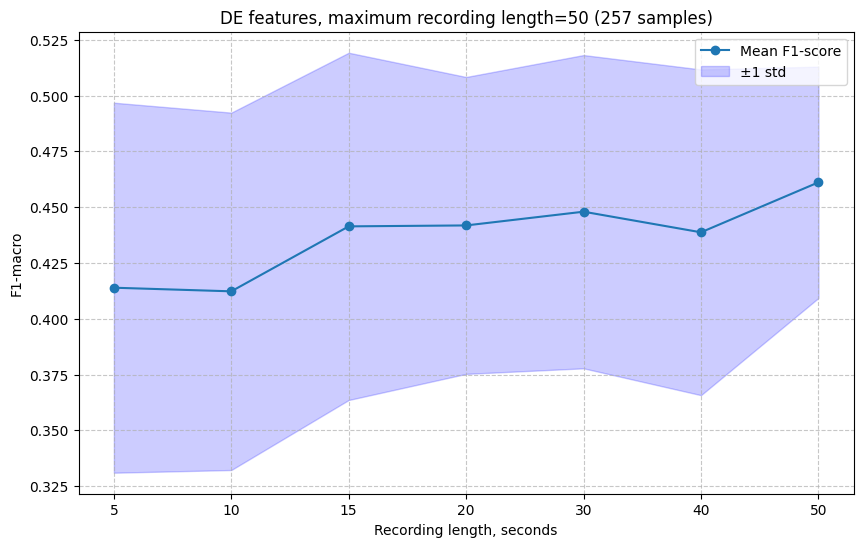

In [72]:
with open('results/de_5_50.json', 'r') as f:
    results = json.load(f)
    
keys = list(results.keys())
means = [np.mean(x) for x in results.values()]
stds = [np.std(x) for x in results.values()]
plt.figure(figsize=(10, 6))
plt.plot(keys, means, marker='o', label='Mean F1-score')
plt.fill_between(keys, 
                 np.array(means) - np.array(stds), 
                 np.array(means) + np.array(stds), 
                 color='blue', alpha=0.2, label='±1 std')
plt.xticks(keys, labels=keys)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xlabel('Recording length, seconds')
plt.ylabel('F1-macro')
plt.title('DE features, maximum recording length=50 (257 samples)')
plt.show()

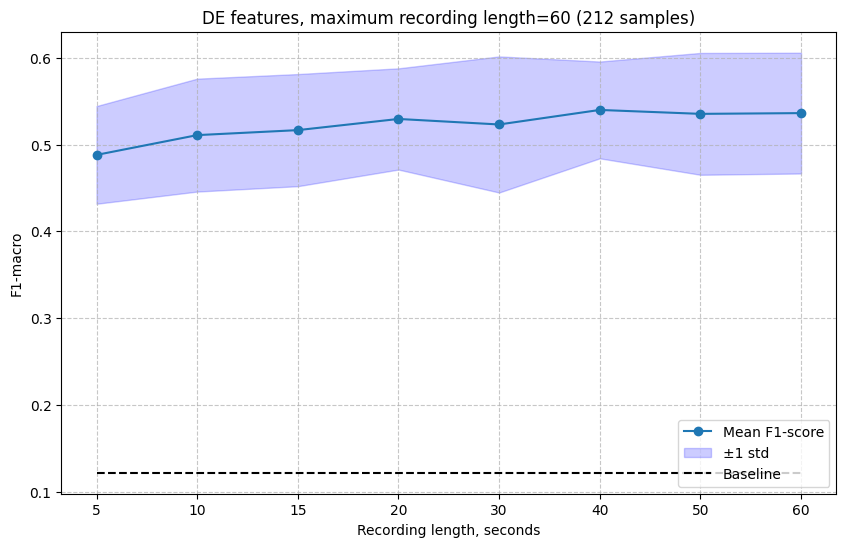

In [17]:
with open('results/de_5_60.json', 'r') as f:
    results = json.load(f)
    
keys = list(results.keys())
means = [np.mean(x) for x in results.values()]
stds = [np.std(x) for x in results.values()]
plt.figure(figsize=(10, 6))

plt.plot(keys, means, marker='o', label='Mean F1-score')
plt.fill_between(keys, 
                 np.array(means) - np.array(stds), 
                 np.array(means) + np.array(stds), 
                 color='blue', alpha=0.2, label='±1 std')

plt.plot(keys, [baseline_mean] * len(keys), linestyle='--', color='black', label='Baseline')

plt.xticks(keys, labels=keys)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.xlabel('Recording length, seconds')
plt.ylabel('F1-macro')
plt.title('DE features, maximum recording length=60 (212 samples)')
plt.show()

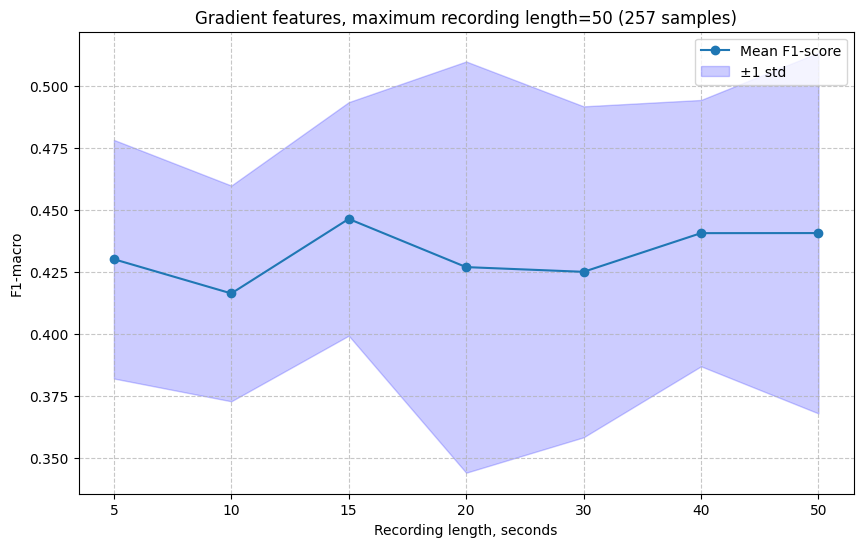

In [74]:
with open('results/grad_5_50.json', 'r') as f:
    results = json.load(f)
    
keys = list(results.keys())
means = [np.mean(x) for x in results.values()]
stds = [np.std(x) for x in results.values()]
plt.figure(figsize=(10, 6))
plt.plot(keys, means, marker='o', label='Mean F1-score')
plt.fill_between(keys, 
                 np.array(means) - np.array(stds), 
                 np.array(means) + np.array(stds), 
                 color='blue', alpha=0.2, label='±1 std')
plt.xticks(keys, labels=keys)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xlabel('Recording length, seconds')
plt.ylabel('F1-macro')
plt.title('Gradient features, maximum recording length=50 (257 samples)')
plt.show()

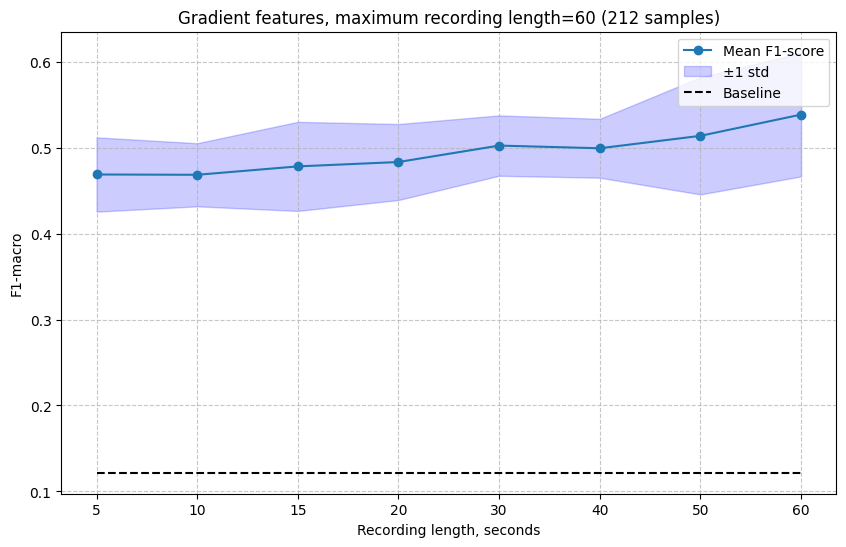

In [18]:
with open('results/grad_5_60.json', 'r') as f:
    results = json.load(f)
    
keys = list(results.keys())
means = [np.mean(x) for x in results.values()]
stds = [np.std(x) for x in results.values()]
plt.figure(figsize=(10, 6))
plt.plot(keys, means, marker='o', label='Mean F1-score')
plt.fill_between(keys, 
                 np.array(means) - np.array(stds), 
                 np.array(means) + np.array(stds), 
                 color='blue', alpha=0.2, label='±1 std')

plt.plot(keys, [baseline_mean] * len(keys), linestyle='--', color='black', label='Baseline')

plt.xticks(keys, labels=keys)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xlabel('Recording length, seconds')
plt.ylabel('F1-macro')
plt.title('Gradient features, maximum recording length=60 (212 samples)')
plt.show()

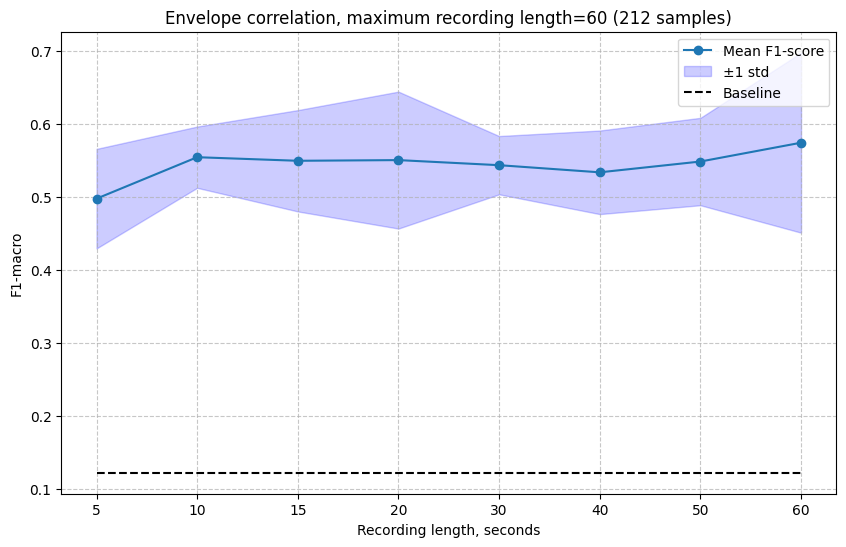

In [19]:
with open('results/envelope_corr_5_60.json', 'r') as f:
    results = json.load(f)
    
keys = list(results.keys())
means = [np.mean(x) for x in results.values()]
stds = [np.std(x) for x in results.values()]
plt.figure(figsize=(10, 6))
plt.plot(keys, means, marker='o', label='Mean F1-score')
plt.fill_between(keys, 
                 np.array(means) - np.array(stds), 
                 np.array(means) + np.array(stds), 
                 color='blue', alpha=0.2, label='±1 std')

plt.plot(keys, [baseline_mean] * len(keys), linestyle='--', color='black', label='Baseline')

plt.xticks(keys, labels=keys)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xlabel('Recording length, seconds')
plt.ylabel('F1-macro')
plt.title('Envelope correlation, maximum recording length=60 (212 samples)')
plt.show()

# Sanity check

In [8]:
def sliding_window_segments(raw, window_length=20, overlap_ratio=0.5, sfreq=250.0):
    """
    Returns list of Raw objects for each window segment.
    """
    window_samples = int(window_length * sfreq)
    step_samples = int(window_samples * (1 - overlap_ratio))
    
    n_samples = raw.shape[-1]
    segments = []
    
    for start in range(0, n_samples - window_samples + 1, step_samples):
        end = start + window_samples
        if end >= n_samples:
            continue
        segment = raw[:, int(start): int(end)]
        segments.append(segment)
    
    return segments

In [9]:
def sliding_window_epochs(raw, info, window_length=20, overlap_ratio=0.5, sfreq=250.0):
    """
    Returns list of Raw objects for each window segment.
    """
    window_samples = int(window_length * sfreq)
    step_samples = int(window_samples * (1 - overlap_ratio))
    
    n_samples = raw.shape[-1]
    segments = []
    
    for start in range(0, n_samples - window_samples + 1, step_samples):
        end = start + window_samples
        if end >= n_samples:
            continue
        segment = raw[:, int(start): int(end)]
        segments.append(mne.io.RawArray(segment, info=info, verbose=False))
    
    return segments

In [10]:
ids = np.argwhere(np.array(lengths_zg) >= 60.0).flatten()
tmp_labels = np.array(zg_labels)[ids]
classes = [label2class[x] for x in tmp_labels]
cnt = Counter(classes)
for k, v in cnt.items():
    print(class2name[k], v)

stress 18
anxiety 18
bipolar 27
control 122
depression 22
personality disorder 5


In [ ]:
n_channels = 19
s_freq = 250

overlaps = [0.5, 0.6, 0.7, 0.8, 0.9]
sec = 60

name_pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('F7', 'F8'), ('C3', 'C4'), ('T3', 'T4'), ('P3', 'P4'), ('T5', 'T6'), ('O1', 'O2')]
idx_pairs = [(0, 1), (2, 4), (5, 6), (9, 11), (7, 8), (14, 16), (12, 13), (17, 18)]
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

results = {}

for over in overlaps:
    cleaned_labels_zg = []
    es_features_zg = []
    de_features_zg = []
    dasm_features_zg = []
    rasm_features_zg = []

    for i in tqdm(ids):
        try:
            path = zg_files[i]
            sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
            if sample.info['sfreq'] != s_freq:
                sample = sample.resample(s_freq, verbose=False)
            # skip faulty data for now
            if 'chan' in sample.ch_names[0].lower():
                continue

            sample = sample.filter(l_freq=6, h_freq=26, method='iir', verbose=False)
            channels = sample.ch_names
            to_drop = channels[19:]

            new_idx = []
            skip = False
            for ch in channels2use:
                found = False
                for k in range(19):
                    if ch in channels[k]:
                        new_idx.append(k)
                        found = True
                        break
                if not found:
                    skip = True
                    break
            if skip:
                continue

            data = sample.get_data()[new_idx, :int(sec * s_freq)]
            segments = sliding_window_segments(data, window_length=20, overlap_ratio=over, sfreq=250.0)

            for seg in segments:
                es, de, dasm, rasm = compute_features(seg, s_freq, idx_pairs)
                es_features_zg.append(es)
                de_features_zg.append(de)
                dasm_features_zg.append(dasm)
                rasm_features_zg.append(rasm)
                cleaned_labels_zg.append(label2class[zg_labels[i]])
        except Exception as e:
            print(e)
            print(path)
    es_features_zg = np.array(es_features_zg)
    de_features_zg = np.array(de_features_zg)
    dasm_features_zg = np.array(dasm_features_zg)
    rasm_features_zg = np.array(rasm_features_zg)
    cleaned_labels_zg = np.array(cleaned_labels_zg)

    if over < 0.7:
        n_splits = 2
    else:
        n_splits = 3

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=92)

    misclassified = []
    mislabelled = []

    labels = cleaned_labels_zg

    for i, (train, test) in enumerate(kf.split(list(range(len(segments))))):
        print(f'start {i}')
        train_ids = []
        test_ids = []

        for j in range(int(len(cleaned_labels_zg) / len(segments))):
            for x in train:
                train_ids.append(x + j * len(segments))
            for x in test:
                test_ids.append(x + j * len(segments))

        X_train = np.concatenate((de_features_zg[train_ids].reshape(-1, 19 * 4 * 20), dasm_features_zg[train_ids].reshape(-1, 8 * 4 * 20), rasm_features_zg[train_ids].reshape(-1, 8 * 4 * 20)), axis=1)
        X_test = np.concatenate((de_features_zg[test_ids].reshape(-1, 19 * 4 * 20), dasm_features_zg[test_ids].reshape(-1, 8 * 4 * 20), rasm_features_zg[test_ids].reshape(-1, 8 * 4 * 20)), axis=1)
        y_train = labels[train_ids]
        y_test = labels[test_ids]
        clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        n_test = len(test)
        misclassified.append(np.sum(preds != y_test) / len(y_test))

        mlbld = 0
        j = 0
        while j < len(y_test):
            p = -1
            different = False
            for _ in range(n_test):
                if p != -1 and preds[j] != p:
                    different = True
                else:
                    p = preds[j]
                j += 1
            if different:
                mlbld += 1
        mislabelled.append(mlbld / (len(y_test) / n_test))
    print(f'mislabelled ratio: {np.mean(mislabelled)}')
    print(f'misclassification rate: {np.mean(misclassified)}')
    results[over] = {'misclassified': np.mean(misclassified), 'mislabelled': np.mean(mislabelled)}


  0%|          | 0/212 [00:00<?, ?it/s]

start 0
start 1
mislabelled ratio: 0.23095238095238096
misclassification rate: 0.3726190476190476


  0%|          | 0/212 [00:00<?, ?it/s]

start 0
start 1
mislabelled ratio: 0.3047619047619048
misclassification rate: 0.3567460317460317


  0%|          | 0/212 [00:00<?, ?it/s]

start 0
start 1
start 2
mislabelled ratio: 0.33015873015873015
misclassification rate: 0.31322751322751324


  0%|          | 0/212 [00:00<?, ?it/s]

start 0
start 1
start 2
mislabelled ratio: 0.4396825396825397
misclassification rate: 0.29470899470899475


In [17]:
with open('results/sanity_check_de.pkl', 'w') as f:
    json.dump(results, f)

In [18]:
s_freq = 250
overlaps = [0.9]
sec = 60

channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(8, 13), (13, 26)]

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}

results = {}

for over in overlaps:
    band2features = {fb: [] for fb in freq_bands}

    for i in tqdm(ids):
        path = zg_files[i]
        try:
            sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
            sample = sample.resample(s_freq, verbose=False)
        except Exception as e:
            print(f'skipped {path}')
            continue
        # skip faulty data for now
        if 'chan' in sample.ch_names[0].lower():
            print(f'skipped {path}')
            continue
        sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
        # get only necessary channels, reorder them
        channels = sample.ch_names
        to_drop = channels[19:]
        sample.drop_channels(to_drop)
        new_idx = []
        skip = False
        for ch in channels2use:
            found = False
            for k in range(19):
                if ch in channels[k]:
                    new_idx.append(k)
                    found = True
                    break
            if not found:
                skip = True
                break
        if skip:
            print(f'skipped {path}')
            continue
        
        data = sample.get_data()[new_idx, :int(sec * s_freq)]
        segments = sliding_window_segments(data, window_length=20, overlap_ratio=over, sfreq=250.0)

        for seg in segments:
            for freq_band in freq_bands:
                psd, freqs = mne.time_frequency.psd_array_multitaper(seg, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
                band2features[freq_band].append({
                    'frontal2parietal': get_frontal2parietal_gradient(channels, psd),
                    'front2back': get_front2back_gradient(channels, psd),
                    'left2right': get_left2right_gradient(channels, psd),
                    'label': zg_labels[i]
                })

    freq_bands = [(8, 13), (13, 26)]
    num_samples = len(band2features[freq_bands[0]])
    frontal2parietal_features = [np.concatenate([band2features[freq_bands[0]][i]['frontal2parietal'], band2features[freq_bands[1]][i]['frontal2parietal']]) for i in range(num_samples)]
    front2back_features = [np.concatenate([band2features[freq_bands[0]][i]['front2back'], band2features[freq_bands[1]][i]['front2back']]) for i in range(num_samples)]
    left2right_features = [np.concatenate([band2features[freq_bands[0]][i]['left2right'], band2features[freq_bands[1]][i]['left2right']]) for i in range(num_samples)]
    labels = [label2class[x['label']] for x in band2features[freq_bands[0]]]

    if over < 0.7:
        n_splits = 2
    elif over < 0.9:
        n_splits = 3
    else:
        n_splits = 4
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=92)
    misclassified = []
    mislabelled = []
    
    features = []
    for i in range(len(labels)):
        features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i]]))
    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(segments))))):
        train_ids = []
        test_ids = []
        for j in range(int(len(labels) / len(segments))):
            for x in train:
                train_ids.append(x + j * len(segments))
            for x in test:
                test_ids.append(x + j * len(segments))
        clf = SVC(kernel='linear', random_state=92)
        X_train = np.array(features)[train_ids]
        X_test = np.array(features)[test_ids]
        y_train = np.array(labels)[train_ids]
        y_test = np.array(labels)[test_ids]
        clf.fit(X_train, y_train)   
        preds = clf.predict(X_test)

        n_test = len(test)
        misclassified.append(np.sum(preds != y_test) / len(y_test))

        mlbld = 0
        j = 0
        while j < len(y_test):
            p = -1
            different = False
            for _ in range(n_test):
                if p != -1 and preds[j] != p:
                    different = True
                else:
                    p = preds[j]
                j += 1
            if different:
                mlbld += 1
        mislabelled.append(mlbld / (len(y_test) / n_test))
    print(f'mislabelled ratio: {np.mean(mislabelled)}')
    print(f'misclassification rate: {np.mean(misclassified)}')
    results[over] = {'misclassified': np.mean(misclassified), 'mislabelled': np.mean(mislabelled)}

# with open('results/sanity_check_grad.json', 'w') as f:
#     json.dump(results, f)

  0%|          | 0/212 [00:00<?, ?it/s]

skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EC_free.edf
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/MANUILOVA_ELENA_55_zg.edf
mislabelled ratio: 0.14642857142857144
misclassification rate: 0.054603174603174605


In [ ]:
n_channels = 19
s_freq = 250

overlaps = [0.5, 0.6, 0.7, 0.8]
sec = 60

name_pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('F7', 'F8'), ('C3', 'C4'), ('T3', 'T4'), ('P3', 'P4'), ('T5', 'T6'), ('O1', 'O2')]
idx_pairs = [(0, 1), (2, 4), (5, 6), (9, 11), (7, 8), (14, 16), (12, 13), (17, 18)]
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

results = {}

freq_bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30)
}

for over in overlaps:
    envelopes = []
    correlations = []
    cleaned_labels_zg = []

    for i in tqdm(ids):
        try:
            path = zg_files[i]
            sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
            if sample.info['sfreq'] != s_freq:
                sample = sample.resample(s_freq, verbose=False)
            # skip faulty data for now
            if 'chan' in sample.ch_names[0].lower():
                continue

            sample = sample.filter(l_freq=6, h_freq=26, method='iir', verbose=False)
            channels = sample.ch_names
            to_drop = channels[19:]

            new_idx = []
            skip = False
            for ch in channels2use:
                found = False
                for k in range(19):
                    if ch in channels[k]:
                        new_idx.append(k)
                        found = True
                        break
                if not found:
                    skip = True
                    break
            if skip:
                continue

            data = sample.get_data()[new_idx, :int(sec * s_freq)]
            info = mne.create_info(channels2use, sfreq=s_freq, ch_types='eeg')
            segments = sliding_window_epochs(data, window_length=20, overlap_ratio=over, info=info)

            for seg in segments:
                # envelopes.append(compute_envelope_features(sample, freq_bands))
                correlations.append(compute_correlation_features(seg, freq_bands))
                cleaned_labels_zg.append(label2class[zg_labels[i]])
        except Exception as e:
            print(e)
            print(path)
    # envelopes = np.array(envelopes)
    correlations = np.array(correlations)

    if over < 0.7:
        n_splits = 2
    else:
        n_splits = 3

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=92)

    misclassified = []
    mislabelled = []

    labels = np.array(cleaned_labels_zg)

    for i, (train, test) in enumerate(kf.split(list(range(len(segments))))):
        print(f'start {i}')
        train_ids = []
        test_ids = []

        for j in range(int(len(cleaned_labels_zg) / len(segments))):
            for x in train:
                train_ids.append(x + j * len(segments))
            for x in test:
                test_ids.append(x + j * len(segments))

        X_train = correlations[train_ids]
        X_test = correlations[test_ids]
        y_train = labels[train_ids]
        y_test = labels[test_ids]
        clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        n_test = len(test)
        misclassified.append(np.sum(preds != y_test) / len(y_test))

        mlbld = 0
        j = 0
        while j < len(y_test):
            p = -1
            different = False
            for _ in range(n_test):
                if p != -1 and preds[j] != p:
                    different = True
                else:
                    p = preds[j]
                j += 1
            if different:
                mlbld += 1
        mislabelled.append(mlbld / (len(y_test) / n_test))
    print(f'mislabelled ratio: {np.mean(mislabelled)}')
    print(f'misclassification rate: {np.mean(misclassified)}')
    results[over] = {'misclassified': np.mean(misclassified), 'mislabelled': np.mean(mislabelled)}

with open('results/sanity_check_env.json', 'w') as f:
    json.dump(results, f)


  0%|          | 0/212 [00:00<?, ?it/s]

start 0
start 1
mislabelled ratio: 0.21904761904761905
misclassification rate: 0.2142857142857143


  0%|          | 0/212 [00:00<?, ?it/s]

start 0
start 1
mislabelled ratio: 0.20476190476190476
misclassification rate: 0.10992063492063492


  0%|          | 0/212 [00:00<?, ?it/s]

start 0
start 1
start 2
mislabelled ratio: 0.08095238095238096
misclassification rate: 0.05502645502645503


  0%|          | 0/212 [00:00<?, ?it/s]

start 0


In [ ]:
n_channels = 19
s_freq = 250

overlaps = [0.9]
sec = 60

name_pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('F7', 'F8'), ('C3', 'C4'), ('T3', 'T4'), ('P3', 'P4'), ('T5', 'T6'), ('O1', 'O2')]
idx_pairs = [(0, 1), (2, 4), (5, 6), (9, 11), (7, 8), (14, 16), (12, 13), (17, 18)]
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

freq_bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30)
}

for over in overlaps:
    envelopes = []
    correlations = []
    cleaned_labels_zg = []

    for i in tqdm(ids):
        try:
            path = zg_files[i]
            sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
            if sample.info['sfreq'] != s_freq:
                sample = sample.resample(s_freq, verbose=False)
            # skip faulty data for now
            if 'chan' in sample.ch_names[0].lower():
                continue

            sample = sample.filter(l_freq=6, h_freq=26, method='iir', verbose=False)
            channels = sample.ch_names
            to_drop = channels[19:]

            new_idx = []
            skip = False
            for ch in channels2use:
                found = False
                for k in range(19):
                    if ch in channels[k]:
                        new_idx.append(k)
                        found = True
                        break
                if not found:
                    skip = True
                    break
            if skip:
                continue

            data = sample.get_data()[new_idx, :int(sec * s_freq)]
            info = mne.create_info(channels2use, sfreq=s_freq, ch_types='eeg')
            segments = sliding_window_epochs(data, window_length=20, overlap_ratio=over, info=info)

            for seg in segments:
                # envelopes.append(compute_envelope_features(sample, freq_bands))
                correlations.append(compute_correlation_features(seg, freq_bands))
                cleaned_labels_zg.append(label2class[zg_labels[i]])
        except Exception as e:
            print(e)
            print(path)
    # envelopes = np.array(envelopes)
    correlations = np.array(correlations)

    if over < 0.7:
        n_splits = 2
    else:
        n_splits = 3

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    misclassified = []
    mislabelled = []

    labels = np.array(cleaned_labels_zg)

    for i, (train, test) in enumerate(kf.split(list(range(len(segments))))):
        print(f'start {i}')
        train_ids = []
        test_ids = []

        for j in range(int(len(cleaned_labels_zg) / len(segments))):
            for x in train:
                train_ids.append(x + j * len(segments))
            for x in test:
                test_ids.append(x + j * len(segments))

        X_train = correlations[train_ids]
        X_test = correlations[test_ids]
        y_train = labels[train_ids]
        y_test = labels[test_ids]
        clf = SVC(kernel='linear', class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        n_test = len(test)
        misclassified.append(np.sum(preds != y_test) / len(y_test))

        mlbld = 0
        j = 0
        while j < len(y_test):
            p = -1
            different = False
            for _ in range(n_test):
                if p != -1 and preds[j] != p:
                    different = True
                else:
                    p = preds[j]
                j += 1
            if different:
                mlbld += 1
        mislabelled.append(mlbld / (len(y_test) / n_test))
    print(f'mislabelled ratio: {np.mean(mislabelled)}')
    print(f'misclassification rate: {np.mean(misclassified)}')
    results[over] = {'misclassified': np.mean(misclassified), 'mislabelled': np.mean(mislabelled)}

with open('results/sanity_check_env_v2.json', 'w') as f:
    json.dump(results, f)


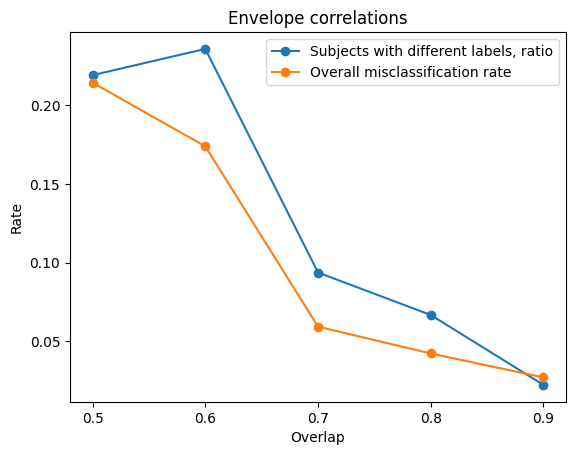

In [11]:
with open('results/sanity_check_env.json', 'r') as f:
    results = json.load(f)

plt.plot(list(results.keys()), [x['mislabelled'] for x in results.values()], marker='o', label='Subjects with different labels, ratio')
plt.plot(list(results.keys()), [x['misclassified'] for x in results.values()], marker='o', label='Overall misclassification rate')
plt.xlabel('Overlap')
plt.ylabel('Rate')
plt.title('Envelope correlations')
plt.legend()
plt.show()

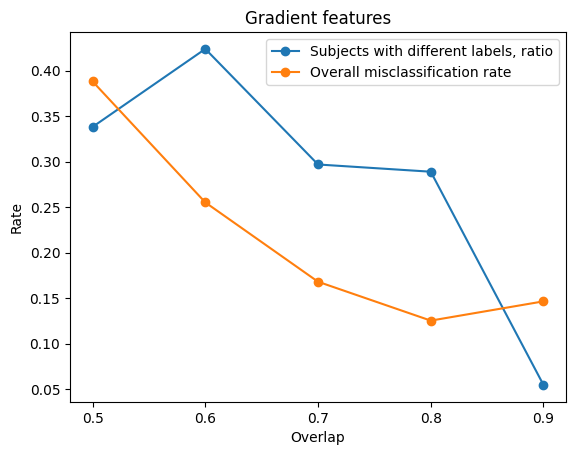

In [13]:
with open('results/sanity_check_grad.json', 'r') as f:
    results = json.load(f)

plt.plot(list(results.keys()), [x['mislabelled'] for x in results.values()], marker='o', label='Subjects with different labels, ratio')
plt.plot(list(results.keys()), [x['misclassified'] for x in results.values()], marker='o', label='Overall misclassification rate')
plt.xlabel('Overlap')
plt.ylabel('Rate')
plt.title('Gradient features')
plt.legend()
plt.show()

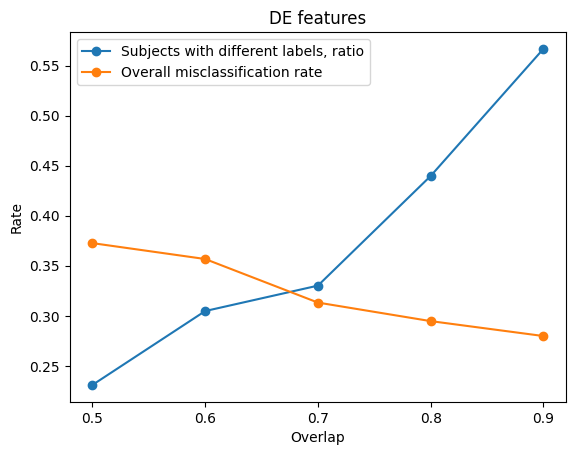

In [15]:
with open('results/sanity_check_de.json', 'r') as f:
    results = json.load(f)

plt.plot(list(results.keys()), [x['mislabelled'] for x in results.values()], marker='o', label='Subjects with different labels, ratio')
plt.plot(list(results.keys()), [x['misclassified'] for x in results.values()], marker='o', label='Overall misclassification rate')
plt.xlabel('Overlap')
plt.ylabel('Rate')
plt.title('DE features')
plt.legend()
plt.show()

# Envelope correlation

In [3]:
import numpy as np
import mne
from scipy.signal import hilbert
from mne_connectivity import envelope_correlation

In [4]:
freq_bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30)
}

def compute_envelope_features(epochs, freq_bands):
    envelope_features = []
    for band, (l_freq, h_freq) in freq_bands.items():
        # Band-pass filter
        epochs_band = epochs.copy().filter(l_freq=l_freq, h_freq=h_freq, verbose=False)
        data = epochs_band.get_data()  # Shape (n_epochs, n_channels, n_times)
        
        # Compute envelope using Hilbert transform
        analytic = hilbert(data)
        envelope = np.abs(analytic)
        
        # Compute statistics (mean and standard deviation)
        mean_env = np.mean(envelope, axis=-1)  # (n_epochs, n_channels)
        std_env = np.std(envelope, axis=-1)
        
        # Concatenate features for this band
        features = np.concatenate([mean_env, std_env], axis=0)
        envelope_features.append(features)
    
    return np.hstack(envelope_features)

def compute_correlation_features(epochs, freq_bands, low_pass=4, new_sfreq=8):
    corr_features = []
    sfreq = epochs.info['sfreq']
    
    for band, (l_freq, h_freq) in freq_bands.items():
        # Band-pass filter
        epochs_band = epochs.copy().filter(l_freq=l_freq, h_freq=h_freq, verbose=False)
        data = epochs_band.get_data()  # Shape (n_epochs, n_channels, n_times)
        
        # Compute envelope
        analytic = hilbert(data)
        envelope = np.abs(analytic)
        
        # Low-pass filter the envelope
        envelope_low = mne.filter.filter_data(
            envelope, sfreq=sfreq, l_freq=None, h_freq=low_pass, method='iir', verbose=False
        )
        
        # Downsample the envelope
        envelope_down = mne.filter.resample(
            envelope_low, down=sfreq / new_sfreq, axis=-1, verbose=False
        )
        
        # Compute envelope correlations
        n_channels, _ = envelope_down.shape
        corr = np.corrcoef(envelope_down)
        
        # Extract upper triangle indices
        triu_inds = np.triu_indices(n_channels, k=1)
        corr_flat = corr[triu_inds[0], triu_inds[1]]
        corr_features.append(corr_flat)
    
    return np.hstack(corr_features)

In [12]:
ids = np.argwhere(np.array(lengths_zg) >= 20.0).flatten()
tmp_labels = np.array(zg_labels)[ids]
classes = [label2class[x] for x in tmp_labels]
cnt = Counter(classes)
for k, v in cnt.items():
    print(class2name[k], v)

stress 57
anxiety 81
bipolar 61
control 155
depression 107
personality disorder 54


## Best model

In [ ]:
from sklearn.model_selection import train_test_split

n_channels = 19
s_freq = 250

sec = 20

name_pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('F7', 'F8'), ('C3', 'C4'), ('T3', 'T4'), ('P3', 'P4'), ('T5', 'T6'), ('O1', 'O2')]
idx_pairs = [(0, 1), (2, 4), (5, 6), (9, 11), (7, 8), (14, 16), (12, 13), (17, 18)]
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

results = {}

cleaned_labels_zg = []
envelopes = []
correlations = []

for i in tqdm(ids):
    try:
        path = zg_files[i]
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
        sample = sample.resample(s_freq, verbose=False)
        # skip faulty data for now
        if 'chan' in sample.ch_names[0].lower():
            continue

        sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
        channels = sample.ch_names
        to_drop = channels[19:]

        new_idx = []
        skip = False
        for ch in channels2use:
            found = False
            for k in range(19):
                if ch in channels[k]:
                    new_idx.append(k)
                    found = True
                    break
            if not found:
                skip = True
                break
        if skip:
            continue

        # data = sample.get_data()[new_idx, :int(sec * s_freq)]
        # sampl
        sample = sample.pick_channels([channels[j] for j in new_idx], verbose=False)

        # envelopes.append(compute_envelope_features(sample, freq_bands))
        correlations.append(compute_correlation_features(sample, freq_bands))
        cleaned_labels_zg.append(label2class[zg_labels[i]])
    except Exception as e:
        print(e)
        print(path)
# envelopes = np.array(envelopes)
correlations = np.array(correlations)
cleaned_labels_zg = np.array(cleaned_labels_zg)

train_X, test_X, train_y, test_y = train_test_split(correlations, cleaned_labels_zg, test_size=0.2, random_state=92)

f1_scores_macro = []
f1_scores_micro = []
accuracies = []

clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
clf.fit(train_X, train_y)
preds = clf.predict(test_X)
print(f1_score(test_y, preds, average='macro'))

  0%|          | 0/515 [00:00<?, ?it/s]

0.34432693531958236


In [20]:
train_X, test_X, train_y, test_y = train_test_split(correlations, cleaned_labels_zg, test_size=0.2, random_state=42)

clf = SVC(kernel='linear', class_weight='balanced', random_state=92, probability=True)
clf.fit(train_X, train_y)
preds = clf.predict(test_X)
print(f1_score(test_y, preds, average='macro'))

0.4024463630513237


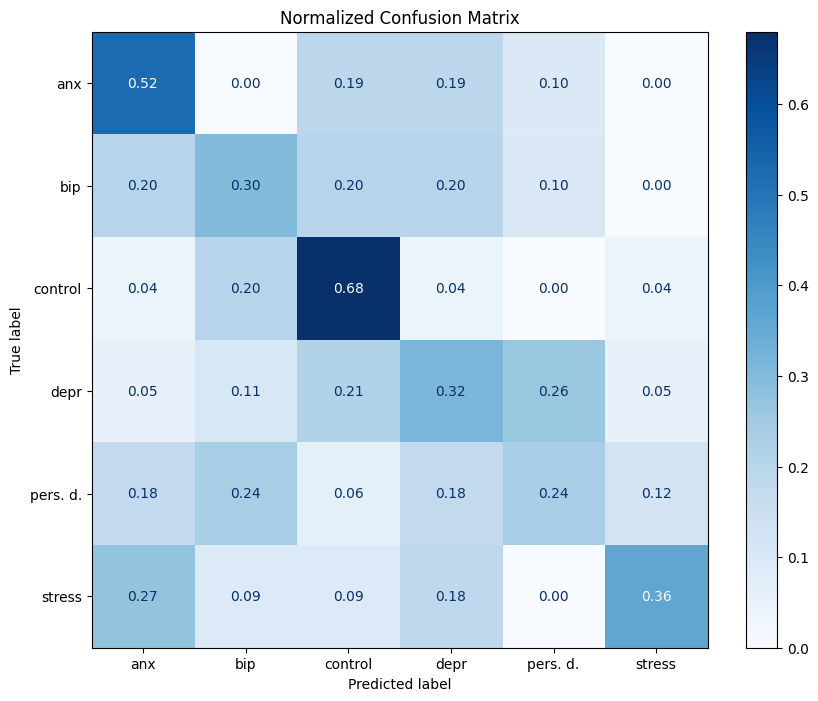

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

y_pred = clf.predict(test_X)

cm = confusion_matrix(test_y, y_pred)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized,
                              display_labels=['anx', 'bip', 'control', 'depr', 'pers. d.', 'stress'])

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', values_format='.2f')

ax.set_title('Normalized Confusion Matrix')
plt.show()

In [21]:
y_test = test_y
X_test = test_X

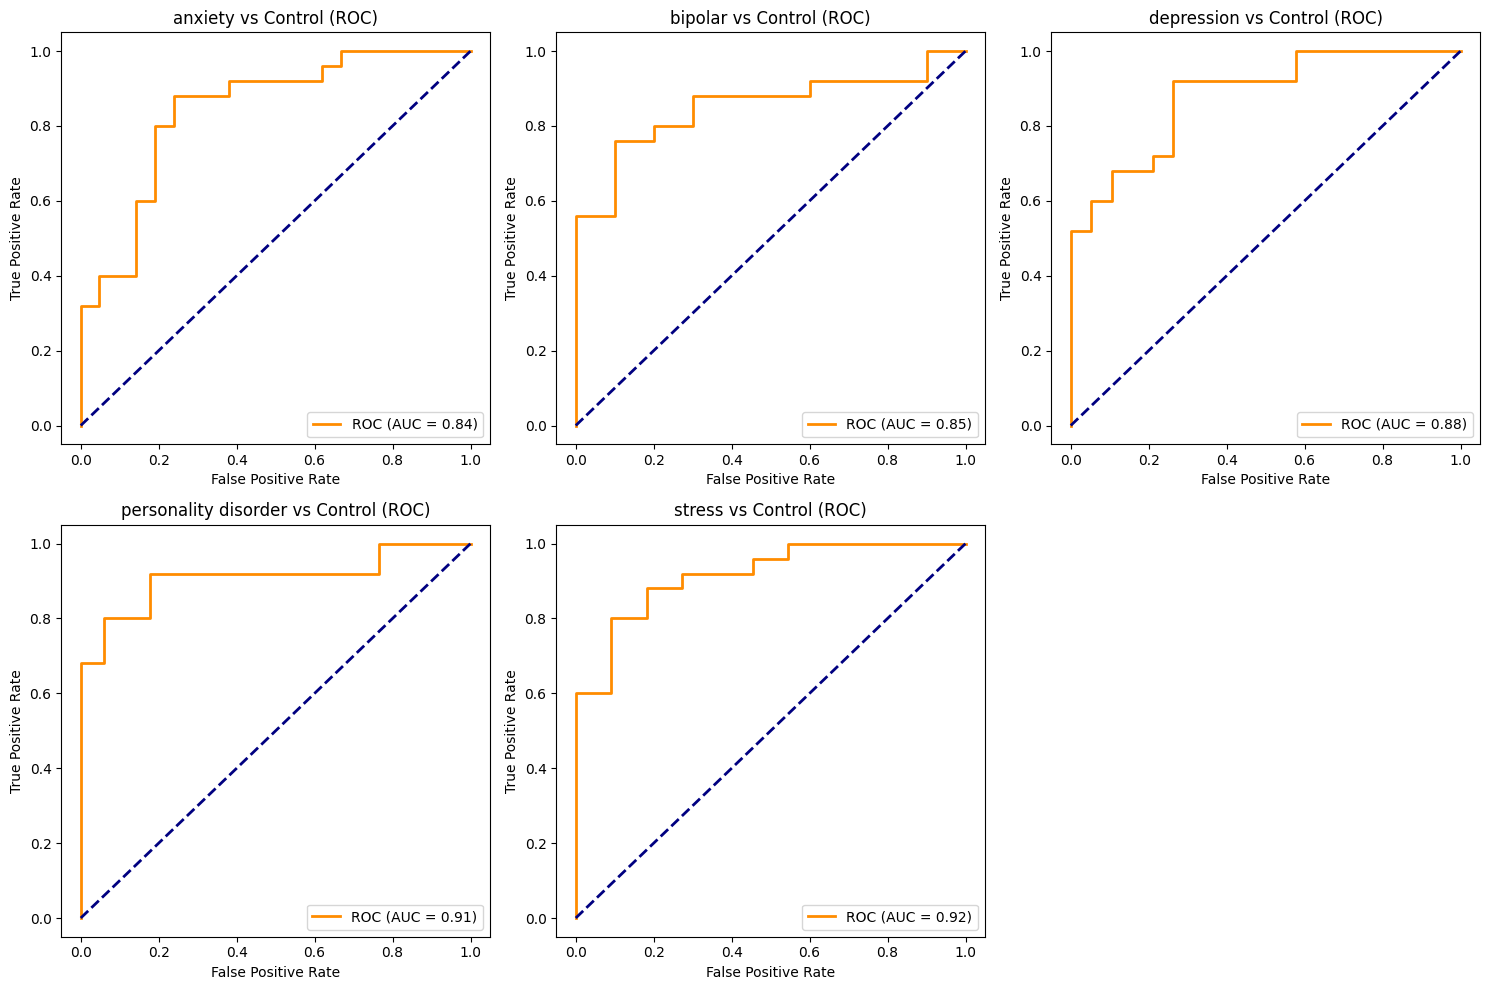

ROC AUC Scores: {0: 0.8438095238095239, 1: 0.8520000000000001, 3: 0.88, 4: 0.9105882352941177, 5: 0.9163636363636364}
PR AUC Scores: {0: 0.8642164301406527, 1: 0.9456100215348748, 3: 0.9155360789308159, 4: 0.9518363257415889, 5: 0.9633493455123586}


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split

# Define classes (assuming 'control' is index 2)
pathologies = [0, 1, 3, 4, 5]
control_class = 2

# Store results
roc_aucs = {}
pr_aucs = {}

# Initialize plots
plt.figure(figsize=(15, 10))

# --- Loop through each pathology ---
for i, pathology in enumerate(pathologies):
    # 1. Filter data (only pathology + control)
    pathology_mask = (y_test == pathology) | (y_test == control_class)
    X_test_subset = X_test[pathology_mask]
    y_test_subset = y_test[pathology_mask]
    
    # 2. Binarize labels (1 for pathology, 0 for control)
    y_test_binary = (y_test_subset == control_class).astype(int)
    
    # 3. Predict probabilities for the pathology class
    # (Note: `clf.classes_` must match the order in predict_proba)
    proba_pathology = clf.predict_proba(X_test_subset)[:, clf.classes_.tolist().index(control_class)]
    
    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test_binary, proba_pathology)
    roc_auc = auc(fpr, tpr)
    roc_aucs[pathology] = roc_auc
    
    # --- PR Curve ---
    precision, recall, _ = precision_recall_curve(y_test_binary, proba_pathology)
    pr_auc = average_precision_score(y_test_binary, proba_pathology)
    pr_aucs[pathology] = pr_auc
    
    # --- Plotting ---
    # ROC
    plt.subplot(2, 3, i+1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{class2name[pathology]} vs Control (ROC)')
    plt.legend(loc='lower right')
    
    # # PR
    # plt.subplot(2, 3, i+2)
    # plt.plot(recall, precision, color='blue', lw=2, label=f'PR (AP = {pr_auc:.2f})')
    # plt.xlabel('Recall')
    # plt.ylabel('Precision')
    # plt.title(f'{class2name[pathology]} vs Control (PR)')
    # plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print AUC scores
print("ROC AUC Scores:", roc_aucs)
print("PR AUC Scores:", pr_aucs)

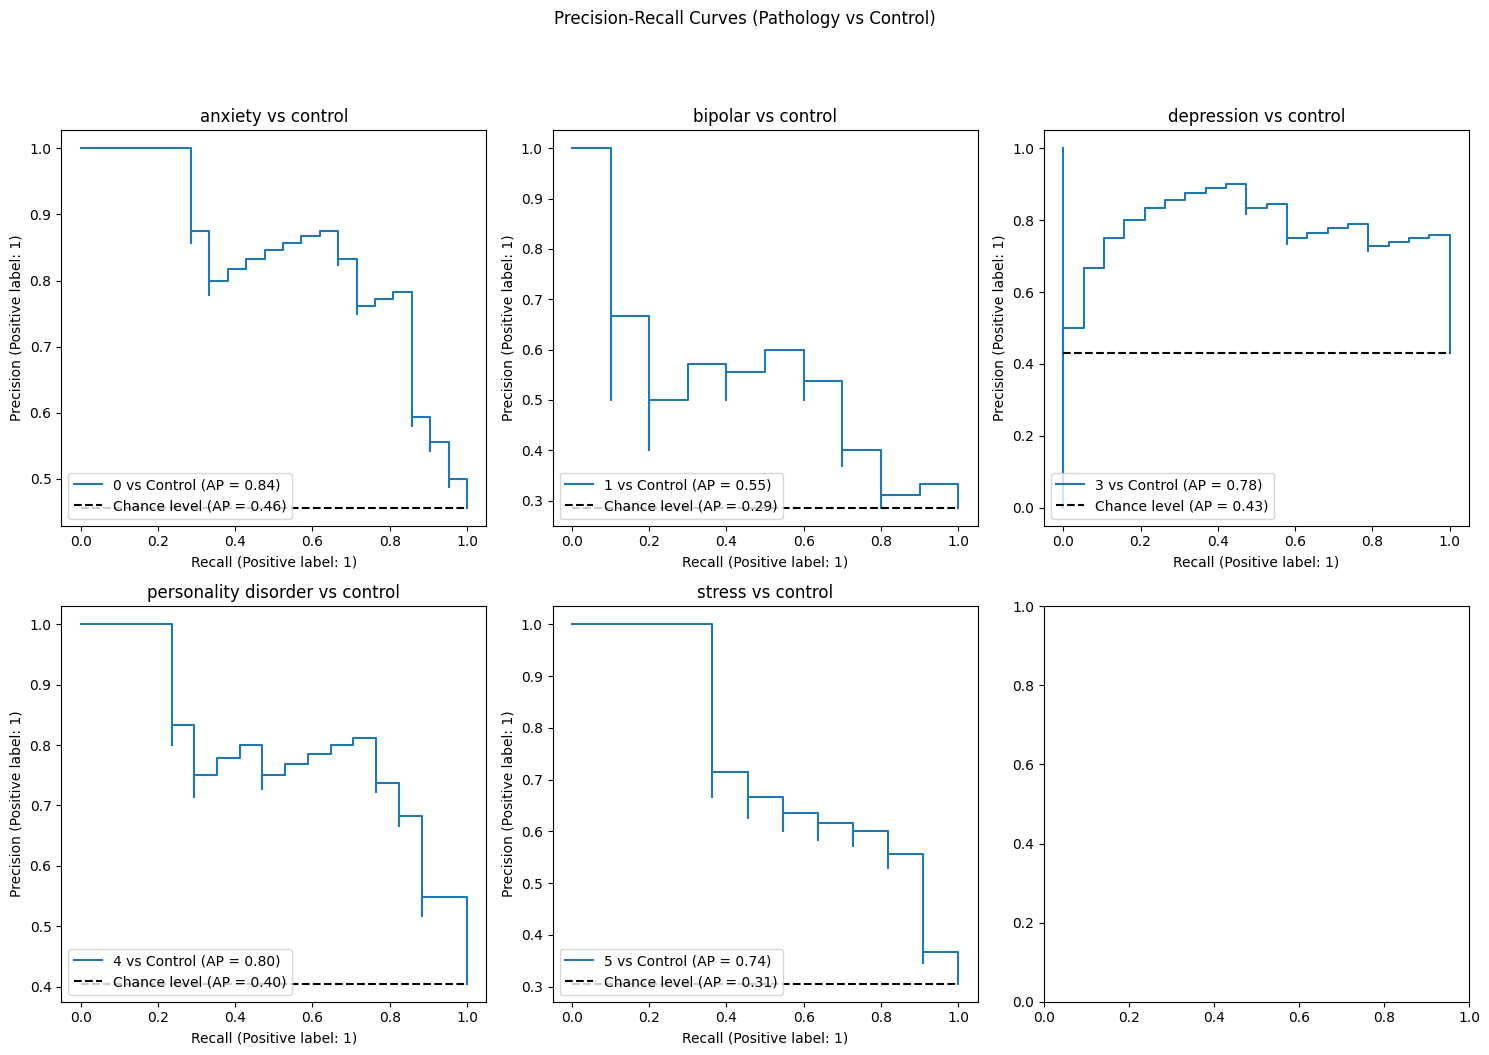

In [23]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt
# Initialize figure
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Precision-Recall Curves (Pathology vs Control)', y=1.05)

col = 0
row = 0

# Loop through each pathology
for i, pathology in enumerate(pathologies):
    # 1. Filter data (only pathology + control)
    mask = (y_test == pathology) | (y_test == control_class)
    X_subset = X_test[mask]
    y_subset = y_test[mask]
    
    # 2. Binarize labels (1 for pathology, 0 for control)
    y_binary = (y_subset == pathology).astype(int)
    
    # 3. Get predicted probabilities for the pathology class
    proba_pathology = clf.predict_proba(X_subset)[:, clf.classes_.tolist().index(pathology)]
    
    # 4. Plot PR curve using PrecisionRecallDisplay
    PrecisionRecallDisplay.from_predictions(
        y_binary,
        proba_pathology,
        name=f'{pathology} vs Control',
        ax=axs[row, col], 
        plot_chance_level=True
    )
    
    axs[row, col].set_title(f'{class2name[pathology]} vs control')
    axs[row, col].legend(loc='lower left')
    col += 1
    if col == 3:
        row += 1
        col = 0

plt.tight_layout()
plt.show()

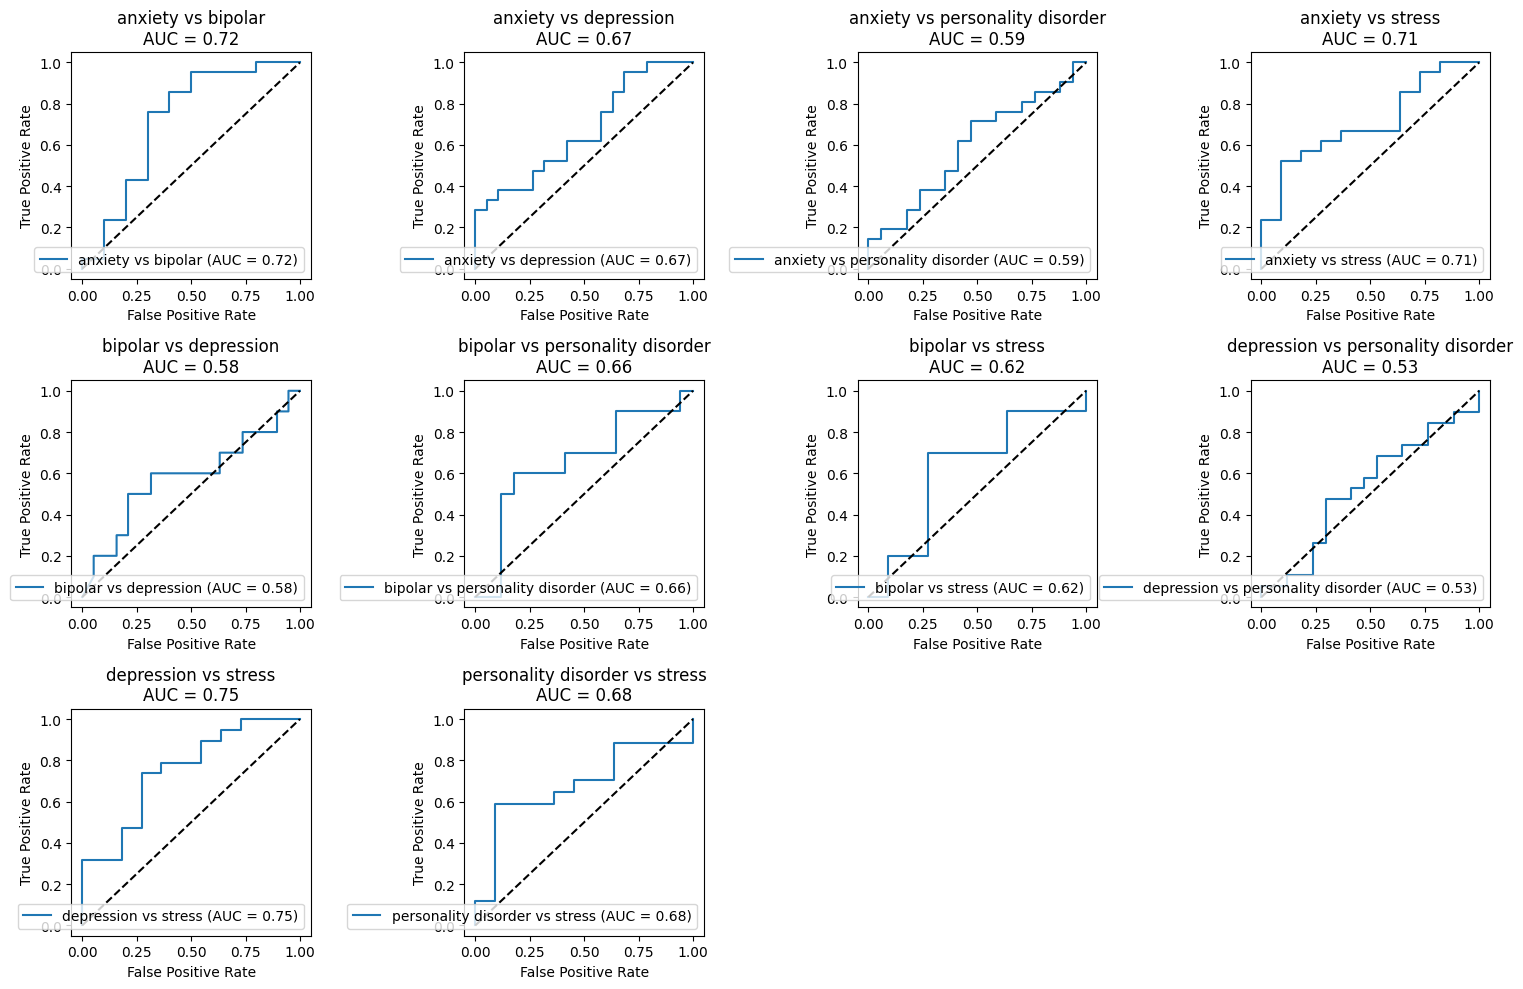

In [24]:
from sklearn.metrics import RocCurveDisplay, auc
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# Define all pathology classes (excluding 'control')
pathologies = [0, 1, 3, 4, 5]

# Generate all possible pairs of pathologies
pathology_pairs = list(combinations(pathologies, 2))

# Initialize figure
plt.figure(figsize=(15, 10))

# Loop through each pathology pair
for i, (class1, class2) in enumerate(pathology_pairs):
    # 1. Filter data (only the two pathologies in the pair)
    mask = (y_test == class1) | (y_test == class2)
    X_pair = X_test[mask]
    y_pair = y_test[mask]
    
    # 2. Binarize labels (1 for class1, 0 for class2)
    y_binary = (y_pair == class1).astype(int)
    
    # 3. Get predicted probabilities for class1
    probs = clf.predict_proba(X_pair)
    proba_class1 = probs[:, clf.classes_.tolist().index(class1)]
    proba_class2 = probs[:, clf.classes_.tolist().index(class2)]
    normed_probs = proba_class1 / (proba_class1 + proba_class2)
    
    # 4. Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_binary, normed_probs)
    roc_auc = auc(fpr, tpr)
    
    # 5. Plot ROC curve
    plt.subplot(3, 4, i+1)  # Adjust subplot grid as needed
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=f'{class2name[class1]} vs {class2name[class2]}').plot(ax=plt.gca())
    plt.title(f'{class2name[class1]} vs {class2name[class2]}\nAUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing

plt.tight_layout()
plt.show()

## Experiments

In [30]:
# calculate features for the first 20s of each recording
n_channels = 19
s_freq = 250

sec = 20

name_pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('F7', 'F8'), ('C3', 'C4'), ('T3', 'T4'), ('P3', 'P4'), ('T5', 'T6'), ('O1', 'O2')]
idx_pairs = [(0, 1), (2, 4), (5, 6), (9, 11), (7, 8), (14, 16), (12, 13), (17, 18)]
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

results = {}

cleaned_labels_zg = []
envelopes = []
correlations = []

for i in tqdm(ids):
    try:
        path = zg_files[i]
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
        sample = sample.resample(s_freq, verbose=False)
        # skip faulty data for now
        if 'chan' in sample.ch_names[0].lower():
            continue

        sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
        channels = sample.ch_names
        to_drop = channels[19:]

        new_idx = []
        skip = False
        for ch in channels2use:
            found = False
            for k in range(19):
                if ch in channels[k]:
                    new_idx.append(k)
                    found = True
                    break
            if not found:
                skip = True
                break
        if skip:
            continue

        # data = sample.get_data()[new_idx, :int(sec * s_freq)]
        # sampl
        sample = sample.pick_channels([channels[j] for j in new_idx], verbose=False)

        envelopes.append(compute_envelope_features(sample, freq_bands))
        correlations.append(compute_correlation_features(sample, freq_bands))
        cleaned_labels_zg.append(label2class[zg_labels[i]])
    except Exception as e:
        print(e)
        print(path)
envelopes = np.array(envelopes)
correlations = np.array(correlations)

  0%|          | 0/515 [00:00<?, ?it/s]

In [44]:
s_freq = 250
sec = 20

channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(8, 13), (13, 26)]

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}

results = {}

band2features = {fb: [] for fb in freq_bands}

cnt = -1

for i in tqdm(ids):
    cnt += 1
    path = zg_files[i]
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
        sample = sample.resample(s_freq, verbose=False)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        print(cnt)
        continue
    
    data = sample.get_data()[new_idx, :int(sec * s_freq)]

    for freq_band in freq_bands:
        psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        band2features[freq_band].append({
            'frontal2parietal': get_frontal2parietal_gradient(channels, psd),
            'front2back': get_front2back_gradient(channels, psd),
            'left2right': get_left2right_gradient(channels, psd),
            'label': zg_labels[i]
        })

freq_bands = [(8, 13), (13, 26)]
num_samples = len(band2features[freq_bands[0]])
frontal2parietal_features = [np.concatenate([band2features[freq_bands[0]][i]['frontal2parietal'], band2features[freq_bands[1]][i]['frontal2parietal']]) for i in range(num_samples)]
front2back_features = [np.concatenate([band2features[freq_bands[0]][i]['front2back'], band2features[freq_bands[1]][i]['front2back']]) for i in range(num_samples)]
left2right_features = [np.concatenate([band2features[freq_bands[0]][i]['left2right'], band2features[freq_bands[1]][i]['left2right']]) for i in range(num_samples)]

  0%|          | 0/515 [00:00<?, ?it/s]

skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EC_free.edf
205
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/MANUILOVA_ELENA_55_zg.edf
255
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/controls (157)/Martinenko_m45_zg.edf
258
skipped /mnt/s3-data2/amiftakhova/OCD/OCD/depression (109)/moderade (47)/FiAV_m50_f32-1_At_Nt_zg.edf
391


In [49]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

labels = cleaned_labels_zg[:511]
new_labels = np.array([labels[i] for i in range(511) if i not in [205, 255, 258, 391]])
new_correlations = np.array([correlations[i] for i in range(511) if i not in [205, 255, 258, 391]])


features = []
for i in range(len(new_labels)):
    features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i]]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.hstack((np.array(features)[train], new_correlations[train]))
    X_test = np.hstack((np.array(features)[test], new_correlations[test]))
    y_train = new_labels[train]
    y_test = new_labels[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))
print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')
results[sec] = f1_scores

	F1 score: 0.35936417558672495, std: 0.029014677572069613


In [25]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []
accuracies = []

labels = np.array(cleaned_labels_zg)

for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = envelopes[train]
    X_test = envelopes[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))

print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')

avg macro-f1: 0.04814434655924062, std: 0.017393422314213404


In [26]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []
accuracies = []

labels = np.array(cleaned_labels_zg)

for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = correlations[train]
    X_test = correlations[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))

print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')

avg macro-f1: 0.4067490491657188, std: 0.05061385548691601


In [41]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []
accuracies = []

labels = np.array(cleaned_labels_zg[:511])

for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.concatenate((de_features_zg[train].reshape(-1, 19 * 4 * sec), dasm_features_zg[train].reshape(-1, 8 * 4 * sec), rasm_features_zg[train].reshape(-1, 8 * 4 * sec), correlations[train]), axis=1)
    X_test = np.concatenate((de_features_zg[test].reshape(-1, 19 * 4 * sec), dasm_features_zg[test].reshape(-1, 8 * 4 * sec), rasm_features_zg[test].reshape(-1, 8 * 4 * sec), correlations[test]), axis=1)
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))

print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')

avg macro-f1: 0.35964125324840057, std: 0.04842413965168


In [31]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = [labels[i] for i in new_ids]

for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    X_train = correlations[new_ids][train]
    X_test = correlations[new_ids][test]
    y_train = np.array(new_labels)[train]
    y_test = np.array(new_labels)[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))

print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')

avg macro-f1: 0.4240358300225301, std: 0.0689456094196103


In [27]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []
accuracies = []

labels = np.array(cleaned_labels_zg)

for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.hstack([envelopes[train], correlations[train]])
    X_test = np.hstack([envelopes[test], correlations[test]])
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))

print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')

avg macro-f1: 0.4067490491657188, std: 0.05061385548691601


In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []
accuracies = []

labels = np.array(cleaned_labels_zg)

for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.hstack([envelopes[train], correlations[train]])
    X_test = np.hstack([envelopes[test], correlations[test]])
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))

print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')

In [28]:
# calculate features for the first 20s of each recording
n_channels = 19
s_freq = 250

sec = 20

name_pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('F7', 'F8'), ('C3', 'C4'), ('T3', 'T4'), ('P3', 'P4'), ('T5', 'T6'), ('O1', 'O2')]
idx_pairs = [(0, 1), (2, 4), (5, 6), (9, 11), (7, 8), (14, 16), (12, 13), (17, 18)]
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

results = {}

cleaned_labels_og = []
envelopes = []
correlations = []

for i in tqdm(ids):
    try:
        path = og_files[i]
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
        sample = sample.resample(s_freq, verbose=False)
        # skip faulty data for now
        if 'chan' in sample.ch_names[0].lower():
            continue

        sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
        channels = sample.ch_names
        to_drop = channels[19:]

        new_idx = []
        skip = False
        for ch in channels2use:
            found = False
            for k in range(19):
                if ch in channels[k]:
                    new_idx.append(k)
                    found = True
                    break
            if not found:
                skip = True
                break
        if skip:
            continue

        # data = sample.get_data()[new_idx, :int(sec * s_freq)]
        # sampl
        sample = sample.pick_channels([channels[j] for j in new_idx], verbose=False)

        envelopes.append(compute_envelope_features(sample, freq_bands))
        correlations.append(compute_correlation_features(sample, freq_bands))
        cleaned_labels_og.append(label2class[og_labels[i]])
    except Exception as e:
        print(e)
        print(path)
envelopes = np.array(envelopes)
correlations = np.array(correlations)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores_macro = []
f1_scores_micro = []
accuracies = []

labels = np.array(cleaned_labels_og)

for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.hstack([envelopes[train], correlations[train]])
    X_test = np.hstack([envelopes[test], correlations[test]])
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores_macro.append(f1_score(y_test, preds, average='macro'))

print(f'avg macro-f1: {np.mean(f1_scores_macro)}, std: {np.std(f1_scores_macro)}')

  0%|          | 0/515 [00:00<?, ?it/s]

avg macro-f1: 0.37365956378603765, std: 0.04898903053760824
